# 06 · Evaluación de la generación fundamentada (Fase 3)

Este notebook **lee un *report* de evaluación** producido por
`scripts/run_generation_eval.py` y construye la **lectura de resultados** de la generación del RAG:
fidelidad, citas, corrección y abstención. Es la pieza que convierte los números crudos del servidor
en la narrativa y las figuras de la memoria.

**Qué NO hace:** no ejecuta el modelo ni el juez (eso es pesado y se hace en el servidor, ver
`docs/run_generation_eval_server.md`). Aquí solo *consumimos* artefactos versionados → es rápido,
reproducible y se puede relanzar con **Kernel → Restart & Run All**.

**Cómo leerlo.** Cada apartado sigue el mismo arco: *qué medimos → qué vemos → cómo interpretarlo*.
La evaluación está organizada en **seis capas** (L1–L6) que localizan *dónde* falla el sistema, no
solo *cuánto* (diseño completo en `docs/evaluacion_gold_y_metricas.md`).

> **Modo DEMO.** Si todavía no existe ningún report en `data/processed/reports/generation/`, el
> notebook genera **datos ilustrativos** (marcados de forma muy visible) usando la taxonomía **real**
> de las 70 preguntas, para que puedas ver el formato y las figuras finales. En cuanto ejecutes el
> *runner* en el servidor, el notebook tomará automáticamente el report real.

## 0 · Configuración y carga del report

Reunimos todas las importaciones y el estilo visual al principio (notebook predecible). El estilo es
deliberadamente sobrio —sin *chartjunk*— con color **semántico**: verde = bien, ámbar = vigilar,
rojo = peligro (p. ej. una respuesta inventada sobre algo no respondible). Después localizamos el
report más reciente; si no hay, entramos en modo DEMO.

In [1]:
import json
import random
from datetime import UTC, datetime
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

%matplotlib inline

# --- Estilo visual sobrio y consistente -----------------------------------------------------------
mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
    }
)

# Paleta semántica (verde=bien · ámbar=vigilar · rojo=peligro · azul=neutro), apta para daltonismo.
PAL = {
    "good": "#2e7d32",
    "warn": "#f9a825",
    "bad": "#c62828",
    "main": "#1565c0",
    "accent": "#6a1b9a",
    "muted": "#b0bec5",
}


def color_for(value, good_thr, warn_thr, higher_better=True):
    """Color semántico de un valor según umbrales (verde/ámbar/rojo)."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return PAL["muted"]
    if higher_better:
        if value >= good_thr:
            return PAL["good"]
        return PAL["warn"] if value >= warn_thr else PAL["bad"]
    if value <= good_thr:
        return PAL["good"]
    return PAL["warn"] if value <= warn_thr else PAL["bad"]


def pct(x):
    return "n/a" if x is None or pd.isna(x) else f"{x * 100:.0f}%"


def hbar(ax, labels, values, colors, fmt="{:.0%}"):
    """Barras horizontales con la etiqueta de valor al lado de cada barra (sin leyenda)."""
    y = range(len(labels))
    ax.barh(list(y), values, color=colors)
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    vmax = max(values) if values else 1
    for i, v in enumerate(values):
        ax.text(v + vmax * 0.01, i, fmt.format(v), va="center", fontsize=9, color="#37474f")
    ax.set_xlim(0, vmax * 1.18)


def kpi_panel(cards, title=None):
    """Fila de tarjetas KPI: número grande + etiqueta, coloreadas por umbral."""
    n = len(cards)
    fig, axes = plt.subplots(1, n, figsize=(2.35 * n, 1.9))
    if n == 1:
        axes = [axes]
    for ax, (label, value, color) in zip(axes, cards, strict=False):
        ax.axis("off")
        ax.add_patch(
            plt.Rectangle(
                (0.02, 0.05),
                0.96,
                0.9,
                transform=ax.transAxes,
                facecolor=color,
                alpha=0.12,
                edgecolor=color,
                lw=1.6,
            )
        )
        ax.text(
            0.5,
            0.60,
            value,
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=19,
            fontweight="bold",
            color=color,
        )
        ax.text(
            0.5,
            0.22,
            label,
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=8.5,
            color="#37474f",
        )
    if title:
        fig.suptitle(title, y=1.02, fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()


# --- Localizar la raíz del repo y los directorios ------------------------------------------------
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS_DIR = ROOT / "data" / "processed" / "reports" / "generation"
DATASET_DIR = ROOT / "data" / "evaluation" / "dense_retrieval_v1"
print(f"Raíz del repositorio: {ROOT}")
print(f"Reports de generación: {REPORTS_DIR}")

Raíz del repositorio: /home/jbailez/repos/rag-legal-boe
Reports de generación: /home/jbailez/repos/rag-legal-boe/data/processed/reports/generation


In [2]:
def _read_jsonl(path):
    if not path.is_file():
        return []
    return [json.loads(li) for li in path.read_text(encoding="utf-8").splitlines() if li.strip()]


def find_latest_report(reports_dir):
    if not reports_dir.is_dir():
        return None
    runs = [p for p in reports_dir.iterdir() if p.is_dir() and (p / "per_query.jsonl").is_file()]
    if not runs:
        return None
    return max(runs, key=lambda p: p.stat().st_mtime)


# Mapa query_id -> texto de la pregunta (para la taxonomía de error).
questions = _read_jsonl(DATASET_DIR / "questions.jsonl")
answer_keys = {a["query_id"]: a for a in _read_jsonl(DATASET_DIR / "answer_keys.jsonl")}
q_text = {q["query_id"]: q["query"] for q in questions}


def _demo_per_query(seed=7):
    """Genera resultados ILUSTRATIVOS sobre la taxonomía real de preguntas (no son reales)."""
    rng = random.Random(seed)
    rows = []
    for q in questions:
        qid = q["query_id"]
        ak = answer_keys.get(qid, {})
        answerable = ak.get("answerable", q["split"] != "out_of_corpus")
        rec = {
            "query_id": qid,
            "split": q["split"],
            "query_style": q["query_style"],
            "failure_mode": q.get("failure_mode"),
            "difficulty": q.get("difficulty", "media"),
            "answerable": answerable,
        }
        if answerable:
            answered = rng.random() > 0.08  # alguna sobre-abstención
            rec["answered"] = answered
            rec["abstention_outcome"] = "answered" if answered else "over_abstention"
            rec["abstention_point"] = (
                "answered" if answered else ("pre_llm" if rng.random() < 0.4 else "llm_decided")
            )
            if answered:
                rec["latency_s"] = round(rng.uniform(28, 75), 1)
                rec["eval_count"] = rng.randint(40, 140)
                rec["faithfulness"] = round(min(1.0, max(0.4, rng.gauss(0.9, 0.12))), 2)
                rec["correctness"] = rng.choices([1.0, 0.5, 0.0], weights=[0.66, 0.24, 0.10])[0]
                rec["citation_precision"] = round(rng.uniform(0.7, 1.0), 2)
                rec["citation_recall"] = round(rng.uniform(0.6, 1.0), 2)
                rec["citation_f1"] = round(
                    2
                    * rec["citation_precision"]
                    * rec["citation_recall"]
                    / (rec["citation_precision"] + rec["citation_recall"]),
                    2,
                )
                if ak.get("key_facts"):
                    rec["key_fact_recall"] = rng.choices(
                        [1.0, 0.5, 0.0], weights=[0.8, 0.13, 0.07]
                    )[0]
                is_trap = q.get("failure_mode") in {"false_premise", "numeric_threshold"}
                rec["hallucinated_forbidden"] = (
                    rng.random() < 0.18 if is_trap else rng.random() < 0.03
                )
        else:
            answered = rng.random() < 0.06  # algún false_answer (peligroso)
            rec["answered"] = answered
            rec["abstention_outcome"] = "false_answer" if answered else "correct_abstention"
            rec["abstention_point"] = (
                "answered" if answered else ("pre_llm" if rng.random() < 0.55 else "llm_decided")
            )
            if answered:
                rec["latency_s"] = round(rng.uniform(28, 75), 1)
                rec["faithfulness"] = round(rng.uniform(0.3, 0.7), 2)
                rec["hallucinated_forbidden"] = True
        rows.append(rec)
    return rows


report_path = find_latest_report(REPORTS_DIR)
IS_DEMO = report_path is None
if IS_DEMO:
    per_query = _demo_per_query()
    config = {
        "split": "(demo)",
        "generator_model": "(demo)",
        "judge_model": "(demo)",
        "bundle_id": "(demo)",
        "query_profile_id": "(demo)",
        "n_questions": len(per_query),
        "generated_at": datetime.now(UTC).isoformat(timespec="seconds"),
    }
    judge_agreement = None
    run_id = "DEMO"
else:
    per_query = _read_jsonl(report_path / "per_query.jsonl")
    config = json.loads((report_path / "config.json").read_text(encoding="utf-8"))
    ja_path = report_path / "judge_agreement.json"
    judge_agreement = json.loads(ja_path.read_text(encoding="utf-8")) if ja_path.is_file() else None
    run_id = report_path.name

df = pd.DataFrame(per_query)
for col in [
    "faithfulness",
    "correctness",
    "citation_f1",
    "citation_precision",
    "citation_recall",
    "key_fact_recall",
    "latency_s",
]:
    if col in df:
        df[col] = pd.to_numeric(df[col], errors="coerce")
if "hallucinated_forbidden" not in df:
    df["hallucinated_forbidden"] = False
df["hallucinated_forbidden"] = df["hallucinated_forbidden"].fillna(False).astype(bool)

if IS_DEMO:
    banner = (
        "[WARN] **MODO DEMO** — datos *ilustrativos* (no reales) sobre la taxonomía real de "
        "preguntas. Ejecuta `scripts/run_generation_eval.py` en el servidor para resultados "
        "reales."
    )
else:
    banner = f"[OK] Report real cargado: `{run_id}`"
display(Markdown(banner))
print(f"Preguntas en el report: {len(df)}  |  run_id: {run_id}")

[OK] Report real cargado: `gen_20260612T143618Z_605b82e4`

Preguntas en el report: 40  |  run_id: gen_20260612T143618Z_605b82e4


## 1 · Marco de evaluación — las seis capas

Evaluar un RAG legal con una sola cifra esconde el problema. Lo descomponemos en seis capas que van
de la recuperación a la respuesta, de modo que cuando algo falle sepamos **en qué componente** está.
El principio rector (estudio de Stanford RegLab sobre IA legal): *correcto*, *fundado en la
evidencia* y *bien citado* **no son lo mismo** y se miden por separado.

In [3]:
capas = pd.DataFrame(
    [
        ["L1", "Retrieval", "¿Está el artículo correcto y arriba?", "ParentnDCG@10, Recall@k"],
        [
            "L2",
            "Contexto",
            "¿El contexto contiene la evidencia y poco ruido?",
            "ContextEvidenceRecall",
        ],
        ["L3", "Fidelidad", "¿Cada afirmación se deriva de la evidencia?", "faithfulness"],
        [
            "L4",
            "Citas",
            "¿La cita soporta de verdad lo que afirma?",
            "citation precision/recall/F1",
        ],
        ["L5", "Corrección", "¿Dice los hechos clave correctos?", "correctness, key-fact recall"],
        ["L6", "Abstención", "¿Se abstiene cuando debe y solo cuando debe?", "balanced accuracy"],
    ],
    columns=["Capa", "Nombre", "Qué mide", "Métrica"],
)
display(capas.style.hide(axis="index"))
display(
    Markdown(
        "> Este notebook cubre **L3–L6** (generación). L1–L2 (retrieval) se evalúan en el "
        "notebook 05 / `benchmark_dense_models.py`."
    )
)

Capa,Nombre,Qué mide,Métrica
L1,Retrieval,¿Está el artículo correcto y arriba?,"ParentnDCG@10, Recall@k"
L2,Contexto,¿El contexto contiene la evidencia y poco ruido?,ContextEvidenceRecall
L3,Fidelidad,¿Cada afirmación se deriva de la evidencia?,faithfulness
L4,Citas,¿La cita soporta de verdad lo que afirma?,citation precision/recall/F1
L5,Corrección,¿Dice los hechos clave correctos?,"correctness, key-fact recall"
L6,Abstención,¿Se abstiene cuando debe y solo cuando debe?,balanced accuracy


> Este notebook cubre **L3–L6** (generación). L1–L2 (retrieval) se evalúan en el notebook 05 / `benchmark_dense_models.py`.

## 2 · Trazabilidad del experimento

Toda figura de la memoria debe poder rastrearse a una ejecución concreta: qué **modelo generador**,
qué **modelo juez**, qué **bundle** denso y qué **perfil de consulta** produjeron estos números.
Sin esta cabecera, los resultados no son reproducibles ni defendibles.

In [4]:
keys = [
    ("split", "Split evaluado"),
    ("generator_model", "Modelo generador"),
    ("judge_model", "Modelo juez (L3/L5)"),
    ("bundle_id", "Bundle denso"),
    ("query_profile_id", "Perfil de consulta"),
    ("top_k", "top_k"),
    ("max_evidences", "Máx. evidencias"),
    ("seed", "Semilla"),
    ("n_questions", "Nº de preguntas"),
    ("generated_at", "Generado en"),
]
meta = pd.DataFrame([(lbl, config.get(k, "—")) for k, lbl in keys], columns=["Parámetro", "Valor"])
display(meta.style.hide(axis="index"))

Parámetro,Valor
Split evaluado,development
Modelo generador,qwen2.5:7b-instruct
Modelo juez (L3/L5),gemma3:12b
Bundle denso,e5-large-instruct__j1__bc11142bdcc5
Perfil de consulta,I2_CITIZEN_LEGISLATION
top_k,5
Máx. evidencias,3
Semilla,42
Nº de preguntas,40
Generado en,—


## 3 · Resumen ejecutivo (KPIs)

Los titulares de un vistazo. Cada tarjeta se colorea por umbral: **verde** = objetivo cumplido,
**ámbar** = a vigilar, **rojo** = problema. La tarjeta más importante para un sistema legal es la de
**respuestas inventadas** (*false answers* sobre preguntas no respondibles): debería ser ~0.

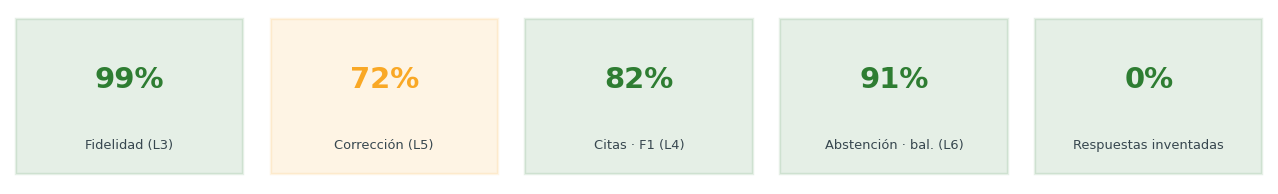

Latencia mediana (CPU): 78 s


In [5]:
def aggregate(df):
    a = {}
    ans = df["answered"].fillna(False).astype(bool)
    able = df["answerable"].fillna(False).astype(bool)
    for m in ["faithfulness", "correctness", "citation_f1", "key_fact_recall"]:
        a[m] = df[m].mean() if m in df and df[m].notna().any() else None
    a["answerable_total"] = int(able.sum())
    a["unanswerable_total"] = int((~able).sum())
    a["answer_rate"] = (ans & able).sum() / able.sum() if able.sum() else None
    a["abstention_rate_unans"] = ((~ans) & (~able)).sum() / (~able).sum() if (~able).sum() else None
    a["false_answer_rate"] = (ans & (~able)).sum() / (~able).sum() if (~able).sum() else None
    a["over_abstention_rate"] = ((~ans) & able).sum() / able.sum() if able.sum() else None
    accs = [x for x in (a["answer_rate"], a["abstention_rate_unans"]) if x is not None]
    a["balanced_accuracy"] = sum(accs) / len(accs) if accs else None
    has_lat = "latency_s" in df and df["latency_s"].notna().any()
    a["latency_p50"] = df["latency_s"].median() if has_lat else None
    return a


agg = aggregate(df)
cards = [
    ("Fidelidad (L3)", pct(agg["faithfulness"]), color_for(agg["faithfulness"], 0.90, 0.75)),
    ("Corrección (L5)", pct(agg["correctness"]), color_for(agg["correctness"], 0.80, 0.60)),
    ("Citas · F1 (L4)", pct(agg["citation_f1"]), color_for(agg["citation_f1"], 0.70, 0.50)),
    (
        "Abstención · bal. (L6)",
        pct(agg["balanced_accuracy"]),
        color_for(agg["balanced_accuracy"], 0.85, 0.70),
    ),
    (
        "Respuestas inventadas",
        pct(agg["false_answer_rate"]),
        color_for(agg["false_answer_rate"], 0.02, 0.10, higher_better=False),
    ),
]
kpi_panel(cards)
lat = agg["latency_p50"]
print(f"Latencia mediana (CPU): {lat:.0f} s" if lat is not None else "Latencia: n/d")

## 4 · ¿Podemos fiarnos del juez? (validez del LLM-juez)

La fidelidad (L3) y la corrección (L5) las decide un **LLM-juez**, no una regla determinista. Antes
de creernos esos números hay que **validar el juez contra un subconjunto anotado a mano** y reportar
el acuerdo (Cohen's κ). Es la lección de ALCE: las métricas con juez solo valen *cuando se validan*.
Un κ por debajo de ~0.6 obliga a tratar L3/L5 como provisionales.

In [6]:
if judge_agreement and judge_agreement.get("n"):
    k = judge_agreement.get("cohens_kappa")
    pa = judge_agreement.get("percent_agreement")
    col = color_for(k, 0.8, 0.6) if k is not None else PAL["muted"]
    kpi_panel(
        [
            ("Acuerdo con humano", pct(pa), color_for(pa, 0.85, 0.7)),
            ("Cohen's κ", f"{k:.2f}" if k is not None else "n/a", col),
            ("n validados", str(judge_agreement["n"]), PAL["main"]),
        ]
    )
    verdict = (
        "κ sustancial: las métricas con juez son fiables."
        if k and k >= 0.6
        else "κ bajo: tratar fidelidad/corrección como PROVISIONALES."
    )
    display(Markdown(f"**Lectura:** {verdict}"))
else:
    msg = (
        "[WARN] **El juez aún no se ha validado contra anotación humana** "
        "(no hay `judge_agreement`). Las métricas de fidelidad y corrección son "
        "**provisionales**: anota a mano ~30–50 casos y compáralos con el juez "
        "(`judge_agreement` en `src/evaluation/judge.py`)."
    )
    display(Markdown(msg))

[WARN] **El juez aún no se ha validado contra anotación humana** (no hay `judge_agreement`). Las métricas de fidelidad y corrección son **provisionales**: anota a mano ~30–50 casos y compáralos con el juez (`judge_agreement` en `src/evaluation/judge.py`).

## 5 · Abstención — los dos errores no son simétricos

Abstenerse bien es seguridad. Hay **dos errores muy distintos**:

- [ERROR] **Respuesta inventada** sobre algo *no respondible* (`false_answer`): el error **peligroso** en
  legal — el sistema afirma con aplomo algo que no está en el corpus.
- [WARN] **Sobre-abstención** sobre algo *respondible* (`over_abstention`): molesto pero **seguro**.

Por eso reportamos *balanced accuracy* (responder y abstenerse pesan igual) y separamos ambos. El
gráfico parte las preguntas en **respondibles** vs **no respondibles** y muestra qué hizo el sistema.

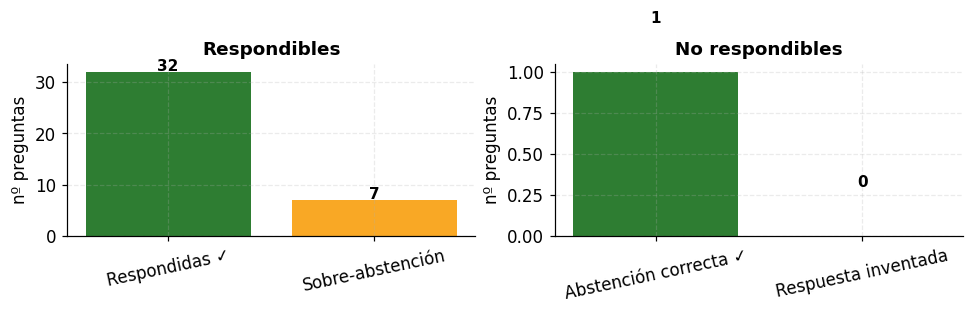

Tasa de respuesta (respondibles):      82%
Tasa de abstención (no respondibles):  100%
Respuestas inventadas (peligroso):     0%
Sobre-abstención:                      18%
Balanced accuracy:                     91%

Punto de abstención: {'llm_decided': 8}
  (pre_llm = abstención barata antes del LLM; llm_decided = la decidió el LLM)


In [7]:
ans = df["answered"].fillna(False).astype(bool)
able = df["answerable"].fillna(False).astype(bool)
groups = {
    "Respondibles": [
        ("Respondidas OK", int((able & ans).sum()), PAL["good"]),
        ("Sobre-abstención", int((able & ~ans).sum()), PAL["warn"]),
    ],
    "No respondibles": [
        ("Abstención correcta OK", int((~able & ~ans).sum()), PAL["good"]),
        ("Respuesta inventada", int((~able & ans).sum()), PAL["bad"]),
    ],
}
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, (titulo, items) in zip(axes, groups.items(), strict=False):
    labels = [i[0] for i in items]
    vals = [i[1] for i in items]
    cols = [i[2] for i in items]
    ax.bar(labels, vals, color=cols)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.3, str(v), ha="center", fontsize=10, fontweight="bold")
    ax.set_title(titulo)
    ax.set_ylabel("nº preguntas")
    ax.tick_params(axis="x", labelrotation=12)
fig.tight_layout()
plt.show()

print(f"Tasa de respuesta (respondibles):      {pct(agg['answer_rate'])}")
print(f"Tasa de abstención (no respondibles):  {pct(agg['abstention_rate_unans'])}")
print(f"Respuestas inventadas (peligroso):     {pct(agg['false_answer_rate'])}")
print(f"Sobre-abstención:                      {pct(agg['over_abstention_rate'])}")
print(f"Balanced accuracy:                     {pct(agg['balanced_accuracy'])}")
if "abstention_point" in df:
    pts = df.loc[~ans, "abstention_point"].value_counts().to_dict()
    print(f"\nPunto de abstención: {pts}")
    print("  (pre_llm = abstención barata antes del LLM; llm_decided = la decidió el LLM)")

## 6 · Fidelidad y citas (L3–L4)

**Fidelidad** = fracción de afirmaciones de la respuesta que se deducen de la evidencia entregada
(idealmente ~1.0: el sistema es *fail-closed*). El histograma muestra la distribución por respuesta;
una cola a la izquierda son respuestas que se "salen" de la evidencia. **Citas**: precisión (no citar
de más), *recall* (citar lo necesario) y su F1.

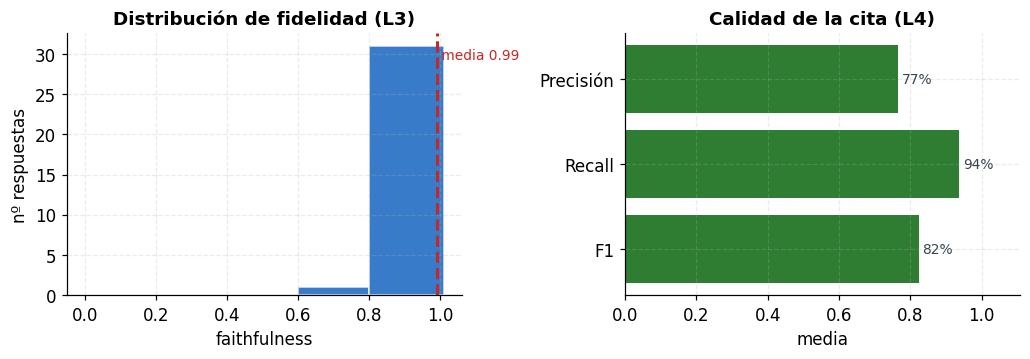

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
ax = axes[0]
if "faithfulness" in df and df["faithfulness"].notna().any():
    vals = df["faithfulness"].dropna()
    ax.hist(
        vals, bins=[0, 0.2, 0.4, 0.6, 0.8, 1.01], color=PAL["main"], alpha=0.85, edgecolor="white"
    )
    ax.axvline(vals.mean(), color=PAL["bad"], lw=2, ls="--")
    ax.text(
        vals.mean(),
        ax.get_ylim()[1] * 0.9,
        f" media {vals.mean():.2f}",
        color=PAL["bad"],
        fontsize=9,
    )
    ax.set_title("Distribución de fidelidad (L3)")
    ax.set_xlabel("faithfulness")
    ax.set_ylabel("nº respuestas")
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "Sin datos de fidelidad\n(requiere juez)", ha="center", color=PAL["muted"])

ax = axes[1]
cmetrics = [
    ("Precisión", "citation_precision"),
    ("Recall", "citation_recall"),
    ("F1", "citation_f1"),
]
labels = [m[0] for m in cmetrics]
vals = [df[m[1]].mean() if m[1] in df and df[m[1]].notna().any() else 0 for m in cmetrics]
cols = [color_for(v, 0.7, 0.5) for v in vals]
hbar(ax, labels, vals, cols)
ax.set_title("Calidad de la cita (L4)")
ax.set_xlabel("media")
fig.tight_layout()
plt.show()

## 7 · Corrección y hechos clave (L5)

**Corrección**: el juez clasifica cada respuesta como *correcta / parcial / incorrecta* frente a la
respuesta de referencia del gold. **Key-fact recall**: comprobación barata y objetiva de que la
respuesta contiene los hechos clave (p. ej. «un mes», «40.000 €»). Y vigilamos los **hechos
prohibidos**: si aparecen, es una **alucinación** (p. ej. responder «tres meses» al plazo de alzada).

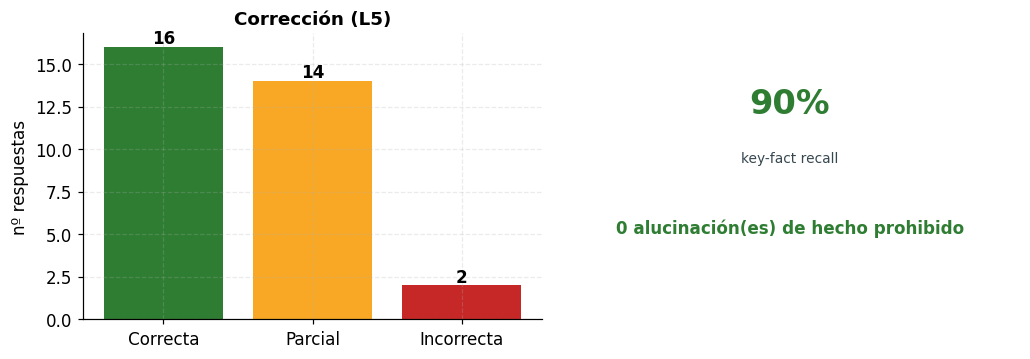

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
ax = axes[0]
if "correctness" in df and df["correctness"].notna().any():
    label_map = {1.0: "Correcta", 0.5: "Parcial", 0.0: "Incorrecta"}
    counts = df["correctness"].dropna().map(label_map).value_counts()
    order = ["Correcta", "Parcial", "Incorrecta"]
    counts = counts.reindex(order).fillna(0)
    cols = [PAL["good"], PAL["warn"], PAL["bad"]]
    ax.bar(order, counts.values, color=cols)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.2, str(int(v)), ha="center", fontweight="bold")
    ax.set_title("Corrección (L5)")
    ax.set_ylabel("nº respuestas")
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "Sin datos de corrección\n(requiere juez)", ha="center", color=PAL["muted"])

ax = axes[1]
has_kfr = "key_fact_recall" in df and df["key_fact_recall"].notna().any()
kfr = df["key_fact_recall"].mean() if has_kfr else None
hall = int(df["hallucinated_forbidden"].sum())
ax.axis("off")
ax.text(
    0.5,
    0.72,
    pct(kfr),
    ha="center",
    fontsize=22,
    fontweight="bold",
    color=color_for(kfr, 0.9, 0.7),
    transform=ax.transAxes,
)
ax.text(
    0.5, 0.55, "key-fact recall", ha="center", fontsize=9, color="#37474f", transform=ax.transAxes
)
ax.text(
    0.5,
    0.30,
    f"{hall} alucinación(es) de hecho prohibido",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color=PAL["bad"] if hall else PAL["good"],
    transform=ax.transAxes,
)
fig.tight_layout()
plt.show()

if hall:
    flagged = df.loc[df["hallucinated_forbidden"], "query_id"].tolist()
    display(Markdown("**[WARN] Respuestas con hecho prohibido (revisar):** " + ", ".join(flagged)))

## 8 · ¿Dónde falla el sistema? Desglose por modo de fallo y dificultad

Aquí está el corazón del **análisis de error**: no basta la media global, hay que ver *qué tipo* de
pregunta falla. Cada pregunta lleva un `failure_mode` (numérica, comparativa, premisa falsa, trampa
temporal, léxica…) y una `difficulty`. Si, por ejemplo, las **numéricas** tienen baja corrección,
sabremos que el cuello de botella es la extracción de cifras y no el retrieval — y eso decide qué
atacar en la fase P2.

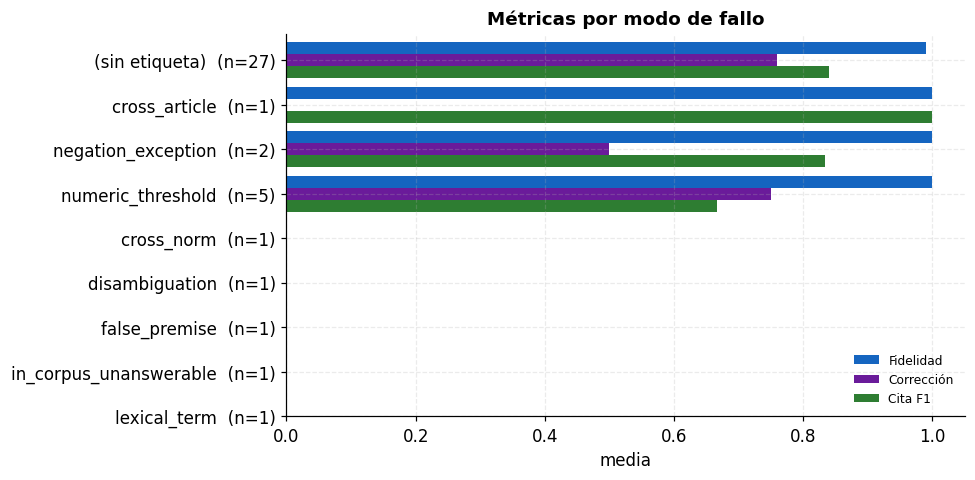

**Por dificultad** (media):

,faithfulness,correctness,citation_f1,n
difficulty,,,,
facil,0.98,0.90,0.87,12
media,1.00,0.63,0.79,21
dificil,1.00,0.67,0.89,7


In [10]:
def grouped_means(df, by, metrics):
    sub = df.copy()
    sub[by] = sub[by].fillna("(sin etiqueta)")
    g = sub.groupby(by)
    out = pd.DataFrame({m: g[m].mean() for _, m in metrics if m in df})
    out["n"] = g.size()
    return out


metrics = [("Fidelidad", "faithfulness"), ("Corrección", "correctness"), ("Cita F1", "citation_f1")]
have = [(lbl, col) for (lbl, col) in metrics if col in df and df[col].notna().any()]

if have:
    by_fm = grouped_means(df, "failure_mode", have).sort_values(have[0][1])
    fig, ax = plt.subplots(figsize=(9, max(3, 0.5 * len(by_fm))))
    width = 0.8 / len(have)
    ys = range(len(by_fm))
    palette = [PAL["main"], PAL["accent"], PAL["good"]]
    for j, (lbl, col) in enumerate(have):
        offs = [y + j * width for y in ys]
        ax.barh(offs, by_fm[col].values, height=width, color=palette[j % 3], label=lbl)
    ax.set_yticks([y + width * (len(have) - 1) / 2 for y in ys])
    ax.set_yticklabels(
        [f"{idx}  (n={int(n)})" for idx, n in zip(by_fm.index, by_fm["n"], strict=False)]
    )
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("media")
    ax.set_title("Métricas por modo de fallo")
    ax.legend(loc="lower right", fontsize=8, frameon=False)
    fig.tight_layout()
    plt.show()
else:
    display(Markdown("_Sin métricas de juez para desglosar (modo sin juez)._"))

if have:
    by_d = (
        grouped_means(df, "difficulty", have)
        .reindex(["facil", "media", "dificil"])
        .dropna(how="all")
    )
    display(Markdown("**Por dificultad** (media):"))
    display(by_d.round(2))

## 8b · Atribución del fallo: ¿recuperación, ensamblado o generación?

Cuando la cita esperada **no** acaba en la respuesta, conviene saber **en qué eslabón se perdió**.
Para cada parent esperado seguimos su rastro con la traza del runner:

- **no recuperado** → ni siquiera salió en el top-k (fallo de *retrieval*, L1);
- **recuperado pero expulsado** → salió, pero el ensamblado lo descartó (p. ej.
  `exceeds_total_context_budget`: una evidencia larga consumió el presupuesto) (L2);
- **entregado pero no citado** → llegó al LLM, que no lo citó (fallo de *generación*, L3–L4);
- **citado OK** → todo correcto.

Esto distingue, por ejemplo, *"el modelo de embeddings falló"* de *"el artículo correcto se
recuperó pero el presupuesto de contexto lo expulsó"* — dos problemas con soluciones distintas.

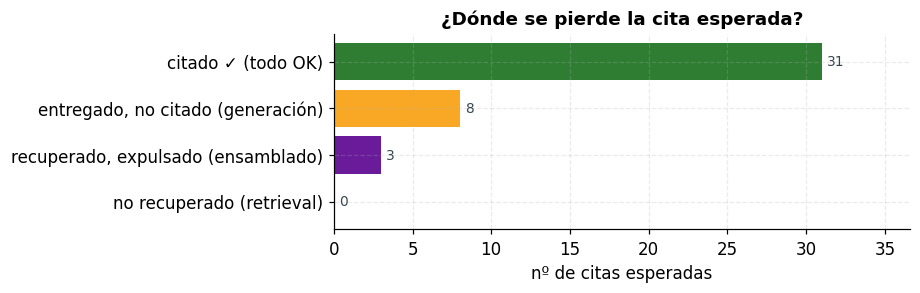

**Citas esperadas que NO se citaron** (etapa del fallo + motivo):

,query_id,failure_mode,parent_esperado,etapa_fallo,motivo,pregunta
0,q0001,numeric_threshold,BOE-A-2015-10565__a21,expulsado,exceeds_total_context_budget,¿Cuánto tiempo tiene la Administración para re...
1,q0002,NaN,BOE-A-2015-10565__a24,no_citado,,Si pido algo a la Administración y no me conte...
2,q0013,NaN,BOE-A-2015-10565__a98,expulsado,,¿Desde cuándo son ejecutivos los actos adminis...
3,q0016,numeric_threshold,BOE-A-2015-10565__a124,no_citado,,¿Cuál es el plazo para presentar un recurso po...
4,q0019,false_premise,BOE-A-2015-10565__a122,no_citado,,¿Por qué el plazo del recurso de alzada es de ...
5,q0032,cross_norm,BOE-A-2013-12887__a24,no_citado,,¿Es el mismo plazo el de la reclamación ante e...
6,q0032,cross_norm,BOE-A-2015-10565__a122,no_citado,,¿Es el mismo plazo el de la reclamación ante e...
7,q0034,NaN,BOE-A-2018-16673__a1-7,no_citado,,¿Cuándo puedo pedir que se supriman mis datos ...
8,q0038,lexical_term,BOE-A-2018-16673__a3-6,expulsado,exceeds_total_context_budget,¿Qué es un DPO en protección de datos?
9,q0039,disambiguation,BOE-A-2015-10565__a122,no_citado,,¿Cuál es el plazo del recurso?


In [11]:
def _aslist(v):
    return v if isinstance(v, list) else []


if {"retrieved_parents", "delivered_parents"}.issubset(df.columns):
    able = df["answerable"].fillna(False).astype(bool)
    stages = {"citado": 0, "no_citado": 0, "expulsado": 0, "no_recuperado": 0}
    fail_rows = []
    for _, r in df[able].iterrows():
        retrieved = _aslist(r.get("retrieved_parents"))
        delivered = _aslist(r.get("delivered_parents"))
        cited = _aslist(r.get("cited_parents"))
        omit = {
            o.get("parent_id"): o.get("reason", "") for o in _aslist(r.get("omitted_evidences"))
        }
        for p in _aslist(r.get("expected_citation_parents")):
            if p in cited:
                stage = "citado"
            elif p in delivered:
                stage = "no_citado"
            elif p in retrieved:
                stage = "expulsado"
            else:
                stage = "no_recuperado"
            stages[stage] += 1
            if stage != "citado":
                fail_rows.append(
                    {
                        "query_id": r["query_id"],
                        "failure_mode": r.get("failure_mode"),
                        "parent_esperado": p,
                        "etapa_fallo": stage,
                        "motivo": omit.get(p, ""),
                    }
                )

    labels = [
        "citado OK (todo OK)",
        "entregado, no citado (generación)",
        "recuperado, expulsado (ensamblado)",
        "no recuperado (retrieval)",
    ]
    keys = ["citado", "no_citado", "expulsado", "no_recuperado"]
    vals = [stages[k] for k in keys]
    cols = [PAL["good"], PAL["warn"], PAL["accent"], PAL["bad"]]
    fig, ax = plt.subplots(figsize=(8.5, 2.8))
    hbar(ax, labels, vals, cols, fmt="{:.0f}")
    ax.set_title("¿Dónde se pierde la cita esperada?")
    ax.set_xlabel("nº de citas esperadas")
    fig.tight_layout()
    plt.show()

    if fail_rows:
        tbl = pd.DataFrame(fail_rows)
        tbl["pregunta"] = tbl["query_id"].map(q_text)
        display(Markdown("**Citas esperadas que NO se citaron** (etapa del fallo + motivo):"))
        display(tbl.reset_index(drop=True))
    else:
        display(Markdown("Todas las citas esperadas se citaron correctamente OK"))
else:
    display(
        Markdown(
            "_Esta vista requiere un report **real** (campos `retrieved_parents` / "
            "`omitted_evidences`); en modo DEMO no se ilustra._"
        )
    )

## 9 · Taxonomía de error — ejemplos concretos

Las medias no se leen solas: hay que **mirar los fallos reales**. Estas tablas listan los casos a
inspeccionar a mano, ordenados por gravedad. Las **respuestas inventadas** y las **alucinaciones de
hecho prohibido** son prioritarias en un sistema legal.

In [12]:
def show_cases(mask, cols_extra, titulo, n=8):
    sub = df.loc[mask].copy()
    if sub.empty:
        display(Markdown(f"**{titulo}:** ninguno OK"))
        return
    sub["pregunta"] = sub["query_id"].map(q_text)
    cols = ["query_id", "failure_mode", "pregunta"] + [c for c in cols_extra if c in sub]
    display(Markdown(f"**{titulo}** ({len(sub)}):"))
    display(sub[cols].head(n).reset_index(drop=True))


ans = df["answered"].fillna(False).astype(bool)
able = df["answerable"].fillna(False).astype(bool)

show_cases(~able & ans, [], "[ERROR] Respuestas inventadas (no respondible pero respondió)")
show_cases(
    df["hallucinated_forbidden"],
    ["faithfulness"],
    "[ERROR] Alucinaciones de hecho prohibido",
)
show_cases(
    able & ~ans,
    ["abstention_reason"],
    "[WARN] Sobre-abstención (respondible pero se abstuvo)",
)
if "faithfulness" in df and df["faithfulness"].notna().any():
    low = df["faithfulness"].notna() & (df["faithfulness"] < 0.8)
    show_cases(low, ["faithfulness"], "[WARN] Menor fidelidad (< 0.80)")

**[ERROR] Respuestas inventadas (no respondible pero respondió):** ninguno OK

**[ERROR] Alucinaciones de hecho prohibido:** ninguno OK

**[WARN] Sobre-abstención (respondible pero se abstuvo)** (7):

,query_id,failure_mode,pregunta,abstention_reason
0,q0002,NaN,Si pido algo a la Administración y no me conte...,La información proporcionada no especifica cla...
1,q0013,NaN,¿Desde cuándo son ejecutivos los actos adminis...,Las evidencias proporcionadas no contienen inf...
2,q0016,numeric_threshold,¿Cuál es el plazo para presentar un recurso po...,No se proporciona información específica sobre...
3,q0019,false_premise,¿Por qué el plazo del recurso de alzada es de ...,Las evidencias proporcionadas no contienen inf...
4,q0032,cross_norm,¿Es el mismo plazo el de la reclamación ante e...,Las evidencias proporcionadas no contienen inf...
5,q0038,lexical_term,¿Qué es un DPO en protección de datos?,La información proporcionada no contiene una d...
6,q0039,disambiguation,¿Cuál es el plazo del recurso?,Las evidencias proporcionadas no contienen inf...


**[WARN] Menor fidelidad (< 0.80)** (1):

,query_id,failure_mode,pregunta,faithfulness
0,q0033,NaN,¿Qué derecho tengo para acceder a mis datos pe...,0.75


## 10 · Coste (latencia)

El MVP corre en **CPU**, así que la latencia importa para la viabilidad como interfaz. Mostramos la
distribución y los percentiles p50/p95: no es un número de UX cómodo todavía, pero permite estudiar
calidad y detectar cuellos de botella.

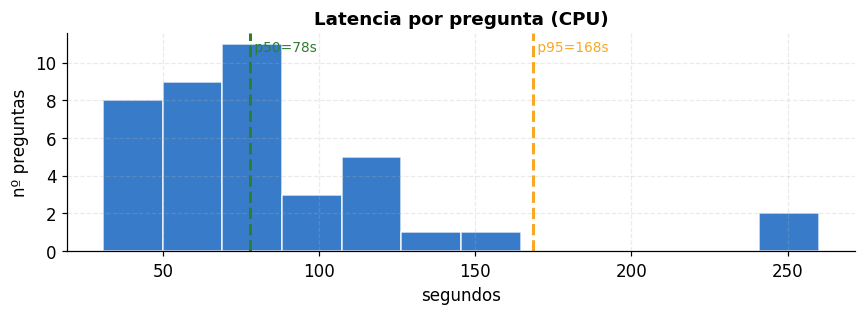

p50=78s · p95=168s · máx=260s


In [13]:
if "latency_s" in df and df["latency_s"].notna().any():
    lat = df["latency_s"].dropna()
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(lat, bins=12, color=PAL["main"], alpha=0.85, edgecolor="white")
    for q, c in [(0.5, PAL["good"]), (0.95, PAL["warn"])]:
        v = lat.quantile(q)
        ax.axvline(v, color=c, lw=2, ls="--")
        ax.text(v, ax.get_ylim()[1] * 0.92, f" p{int(q * 100)}={v:.0f}s", color=c, fontsize=9)
    ax.set_title("Latencia por pregunta (CPU)")
    ax.set_xlabel("segundos")
    ax.set_ylabel("nº preguntas")
    fig.tight_layout()
    plt.show()
    print(f"p50={lat.median():.0f}s · p95={lat.quantile(0.95):.0f}s · máx={lat.max():.0f}s")
else:
    display(Markdown("_Sin datos de latencia en este report._"))

## 11 · Conclusiones, limitaciones y siguientes pasos

**Cómo redactar las conclusiones** (rellena con los números de arriba):

- *Abstención*: ¿es ~0 la tasa de respuestas inventadas? Es el requisito de seguridad nº1.
- *Fidelidad/corrección*: ¿el sistema se ciñe a la evidencia y acierta los hechos clave?
- *Dónde falla*: ¿qué `failure_mode` concentra los errores? Eso prioriza la fase P2.

**Limitaciones a declarar.** (1) Las métricas con juez dependen de su validación (§4). (2) El gold
está en borrador hasta la revisión jurídica (relevancia graduada y `paragraph_orders`). (3) Corpus de
10 normas y una sola ejecución: sin intervalos de confianza todavía.

**Siguientes pasos.** Calibrar el umbral de abstención con la curva *accuracy–coverage*; comparar
estrategias de retrieval (BM25, híbrido, reranker) sobre este mismo gold; ampliar el corpus.

In [14]:
if IS_DEMO:
    tail = "  ·  *(datos DEMO ilustrativos)*"
else:
    tail = (
        f"  ·  generador: `{config.get('generator_model')}`  ·  "
        f"juez: `{config.get('judge_model')}`  ·  bundle: `{config.get('bundle_id')}`"
    )
display(Markdown(f"**Reproducibilidad** — run_id: `{run_id}`" + tail))

**Reproducibilidad** — run_id: `gen_20260612T143618Z_605b82e4`  ·  generador: `qwen2.5:7b-instruct`  ·  juez: `gemma3:12b`  ·  bundle: `e5-large-instruct__j1__bc11142bdcc5`